# let's plot the data to see this years results
a notebook to plot the final analyses

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from matplotlib import pyplot as plt
import re
import numpy as np
import pandas as pd # for data handling

In [3]:
# Load final_df from Excel only if it is not already available
if "final_df" in globals():
    print("final_df is already loaded.")
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        filename, raw_bytes = next(iter(uploaded.items()))
        with open(filename, "wb") as handle:
            handle.write(raw_bytes)
        final_df = pd.read_excel(filename)
    except ImportError:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        selected_file = filedialog.askopenfilename(
            title="Select final_df.xlsx",
            filetypes=[("Excel files", "*.xlsx")]
        )
        root.destroy()

        if selected_file:
            final_df = pd.read_excel(selected_file)
        else:
            raise FileNotFoundError("No Excel file was selected.")

    print("final_df was loaded from Excel.")
    display(final_df.head())

final_df was loaded from Excel.


,source_lif,image_name,#_gephyrin_clusters,#_synaptic_gephyrin_clusters,mean_gephyrin_area_um2,mean_synaptic_gephyrin_area_um2,mean_gephyrin_intensity,mean_synaptic_gephyrin_intensity,total_DAAO_area_um2,pixel_in_x,pixel_in_y
0,Gruppe1 WT + DMet High Density.lif,Image 1,144,66,1.409181,1.711056,8302.701247,8390.788297,1854.083576,0.180375,0.180375
1,Gruppe1 WT + DMet High Density.lif,Image 2,117,47,1.962679,2.525978,8884.198736,9184.781244,3283.062197,0.180375,0.180375
2,Gruppe1 WT + DMet High Density.lif,Image 3,145,63,1.590859,2.037323,8426.103543,8354.226187,1881.966244,0.180375,0.180375
3,Gruppe1 WT + DMet High Density.lif,Image 4,242,131,1.340262,1.705490,8414.915262,8312.351562,3784.364595,0.180375,0.180375
4,Gruppe1 WT + DMet High Density.lif,Image 5,117,54,1.467699,1.672550,8611.679866,9291.339836,3133.400267,0.180375,0.180375


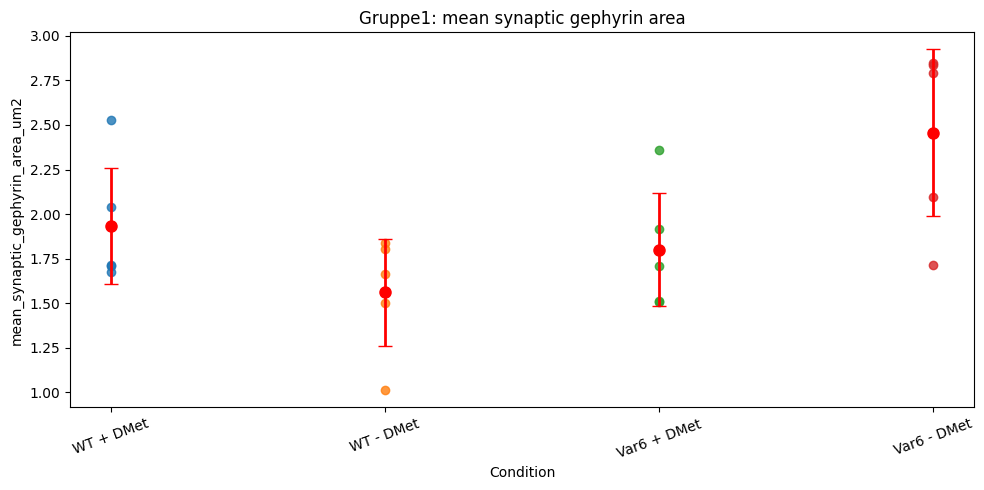

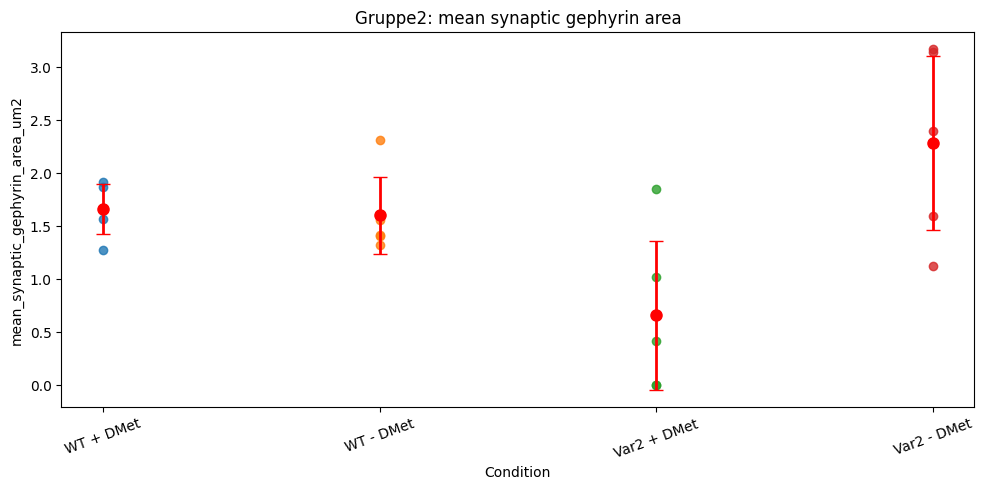

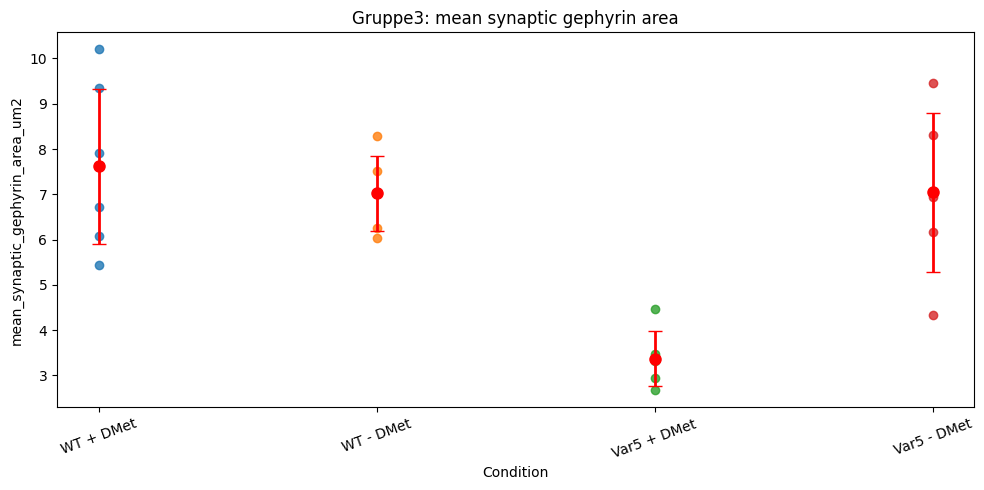

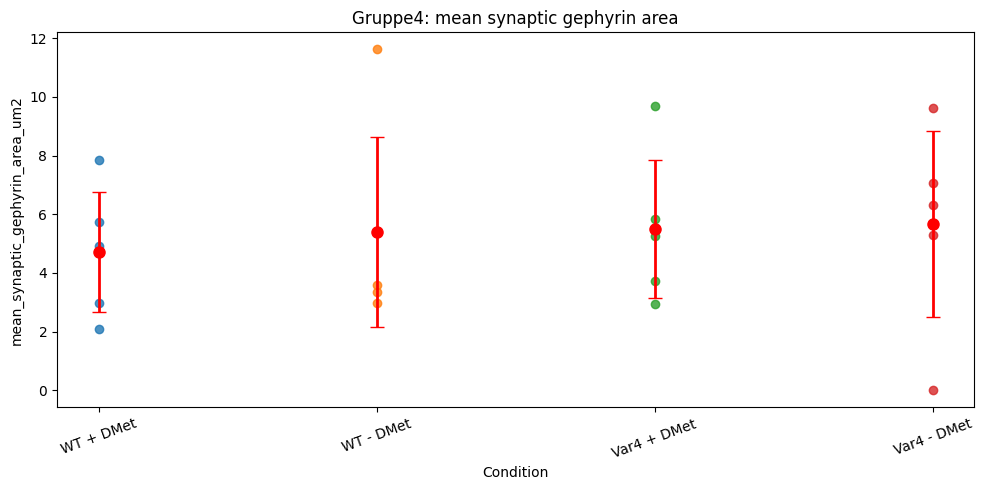

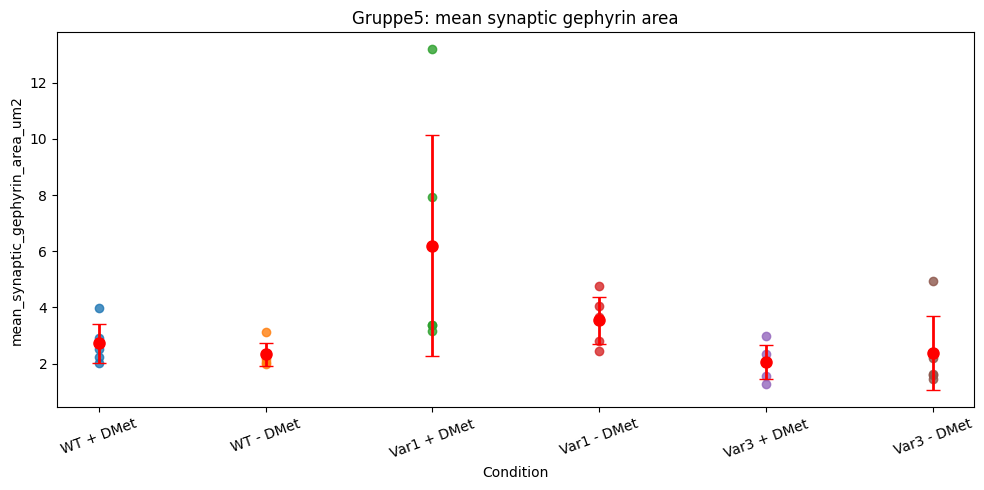

In [9]:
plot_df = final_df.copy()

def read_group_and_condition(source_lif_name):
    text = str(source_lif_name).replace("_", " ")

    group_match = re.search(r"(?:Gruppe|Group)\s*(\d+)", text, flags=re.IGNORECASE)
    condition_match = re.search(r"(WT|Var\s*\d+)\s*([+-])\s*DMet", text, flags=re.IGNORECASE)

    if group_match is None or condition_match is None:
        return None, None

    group_name = f"Gruppe{group_match.group(1)}"

    base_name = condition_match.group(1).replace(" ", "")
    if base_name.upper() == "WT":
        base_name = "WT"
    else:
        variant_number = re.search(r"\d+", base_name).group()
        base_name = f"Var{variant_number}"

    sign = condition_match.group(2)
    condition_name = f"{base_name} {sign} DMet"

    return group_name, condition_name

parsed_values = plot_df["source_lif"].apply(read_group_and_condition)
plot_df["Gruppe"] = parsed_values.str[0]
plot_df["condition"] = parsed_values.str[1]

failed_rows = plot_df[plot_df["Gruppe"].isna() | plot_df["condition"].isna()]
if not failed_rows.empty:
    print("These source_lif values could not be parsed:")
    display(failed_rows[["source_lif"]].drop_duplicates())

plot_df = plot_df.dropna(subset=["Gruppe", "condition"]).copy()

def group_sort_key(group_name):
    return int(re.search(r"\d+", group_name).group())

def condition_sort_key(condition_name):
    if condition_name.startswith("WT"):
        base_order = 0
    else:
        base_order = int(re.search(r"\d+", condition_name).group())

    sign_order = 0 if "+" in condition_name else 1
    return (base_order, sign_order)

all_groups = sorted(plot_df["Gruppe"].unique(), key=group_sort_key)

for group_name in all_groups:
    group_df = plot_df[plot_df["Gruppe"] == group_name].copy()
    conditions = sorted(group_df["condition"].unique(), key=condition_sort_key)

    # Calculate means and standard deviations
    means = []
    stds = []
    for condition_name in conditions:
        values = group_df.loc[
            group_df["condition"] == condition_name,
            "mean_synaptic_gephyrin_area_um2"
        ].dropna().to_numpy()
        means.append(np.mean(values))
        stds.append(np.std(values))

    plt.figure(figsize=(10, 5))
    
    # Plot error bars for mean ± std
    plt.errorbar(range(1, len(conditions)+1), means, yerr=stds, fmt='o', 
                 ecolor='red', color='red', capsize=5, linewidth=2, markersize=8,
                 label='mean ± std', zorder=5)

    for position, condition_name in enumerate(conditions, start=1):
        y_values = group_df.loc[
            group_df["condition"] == condition_name,
            "mean_synaptic_gephyrin_area_um2"
        ].dropna().to_numpy()
        x_values = [position] * len(y_values)
        plt.scatter(x_values, y_values, alpha=0.8, zorder=3)

    plt.title(f"{group_name}: mean synaptic gephyrin area")
    plt.xlabel("Condition")
    plt.ylabel("mean_synaptic_gephyrin_area_um2")
    plt.xticks(range(1, len(conditions)+1), conditions, rotation=20)
    plt.tight_layout()
    plt.show()

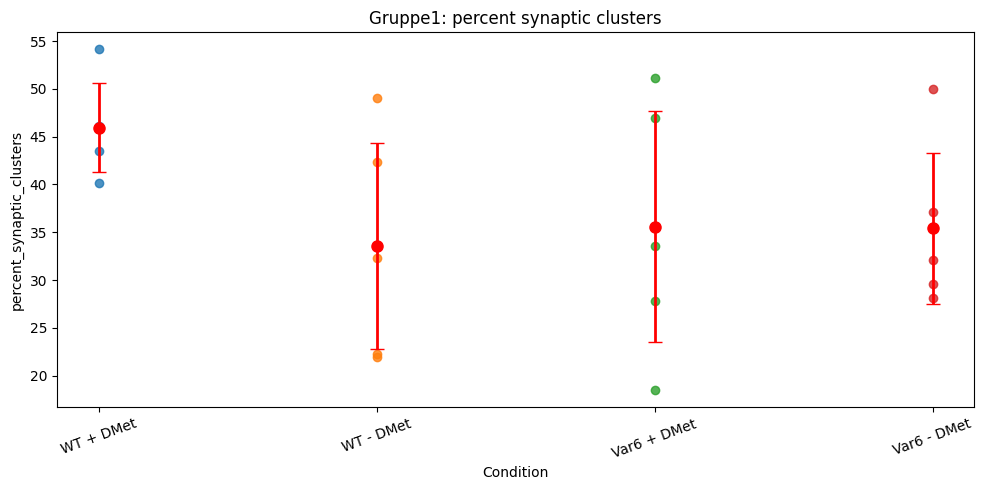

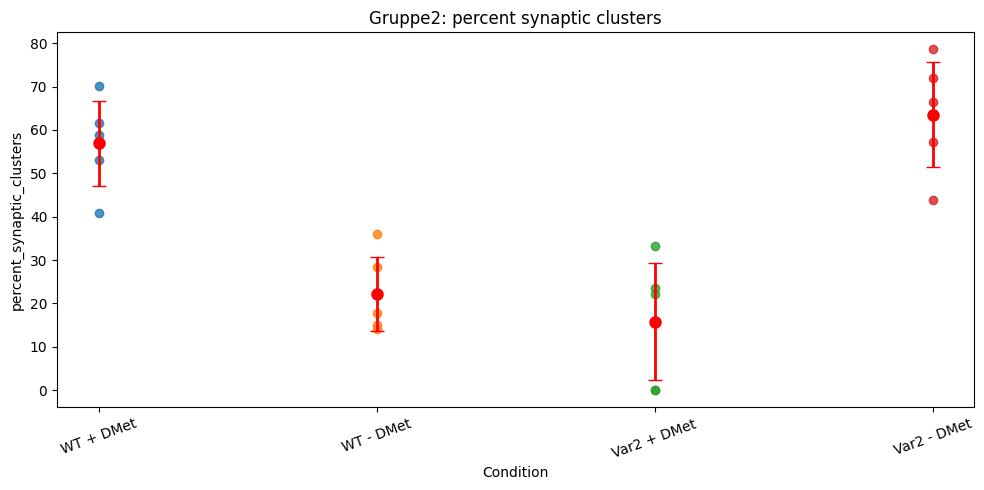

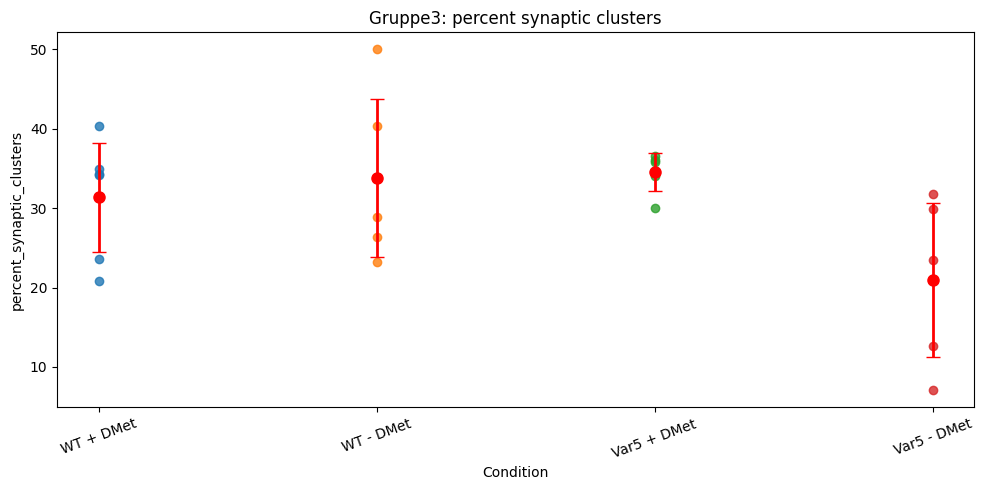

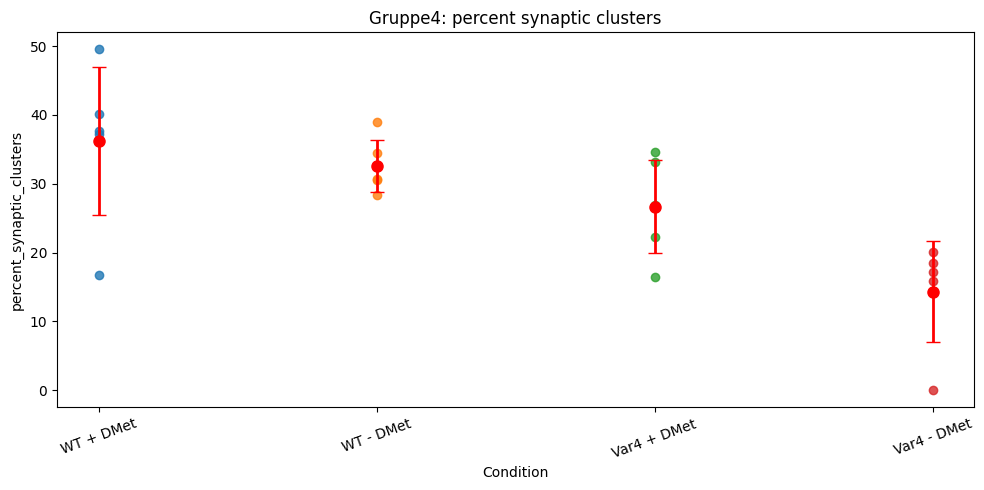

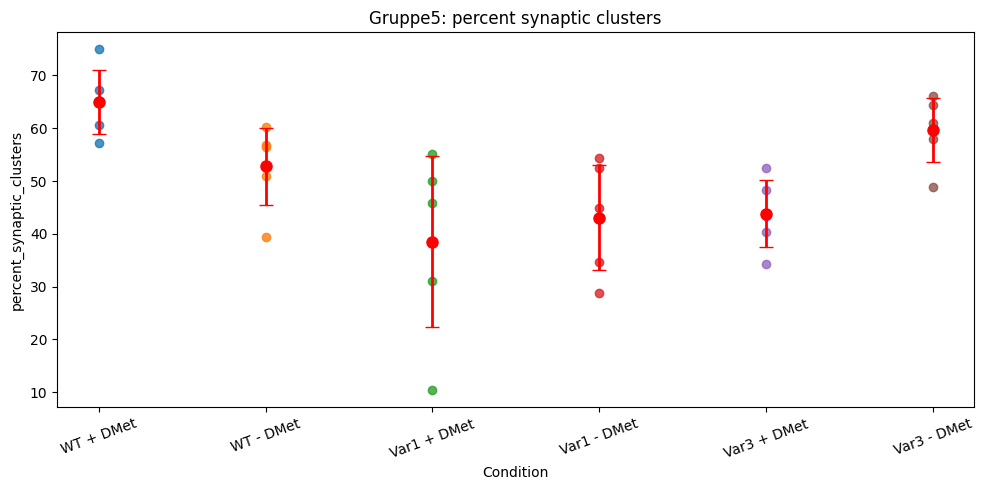

In [10]:
plot_df = final_df.copy()

plot_df["percent_synaptic_clusters"] = (
    plot_df["#_synaptic_gephyrin_clusters"]
    / plot_df["#_gephyrin_clusters"]
    * 100
)

plot_df.loc[plot_df["#_gephyrin_clusters"] == 0, "percent_synaptic_clusters"] = np.nan

parsed_values = plot_df["source_lif"].apply(read_group_and_condition)
plot_df["Gruppe"] = parsed_values.str[0]
plot_df["condition"] = parsed_values.str[1]

failed_rows = plot_df[plot_df["Gruppe"].isna() | plot_df["condition"].isna()]
if not failed_rows.empty:
    print("These source_lif values could not be parsed:")
    display(failed_rows[["source_lif"]].drop_duplicates())

plot_df = plot_df.dropna(subset=["Gruppe", "condition"]).copy()

all_groups = sorted(plot_df["Gruppe"].unique(), key=group_sort_key)

for group_name in all_groups:
    group_df = plot_df[plot_df["Gruppe"] == group_name].copy()
    conditions = sorted(group_df["condition"].unique(), key=condition_sort_key)

    # Calculate means and standard deviations
    means = []
    stds = []
    for condition_name in conditions:
        values = group_df.loc[
            group_df["condition"] == condition_name,
            "percent_synaptic_clusters"
        ].dropna().to_numpy()
        means.append(np.mean(values))
        stds.append(np.std(values))

    plt.figure(figsize=(10, 5))
    
    # Plot error bars for mean ± std
    plt.errorbar(range(1, len(conditions)+1), means, yerr=stds, fmt='o', 
                 ecolor='red', color='red', capsize=5, linewidth=2, markersize=8,
                 label='mean ± std', zorder=5)

    for position, condition_name in enumerate(conditions, start=1):
        y_values = group_df.loc[
            group_df["condition"] == condition_name,
            "percent_synaptic_clusters"
        ].dropna().to_numpy()
        x_values = [position] * len(y_values)
        plt.scatter(x_values, y_values, alpha=0.8, zorder=3)

    plt.title(f"{group_name}: percent synaptic clusters")
    plt.xlabel("Condition")
    plt.ylabel("percent_synaptic_clusters")
    plt.xticks(range(1, len(conditions)+1), conditions, rotation=20)
    plt.tight_layout()
    plt.show()

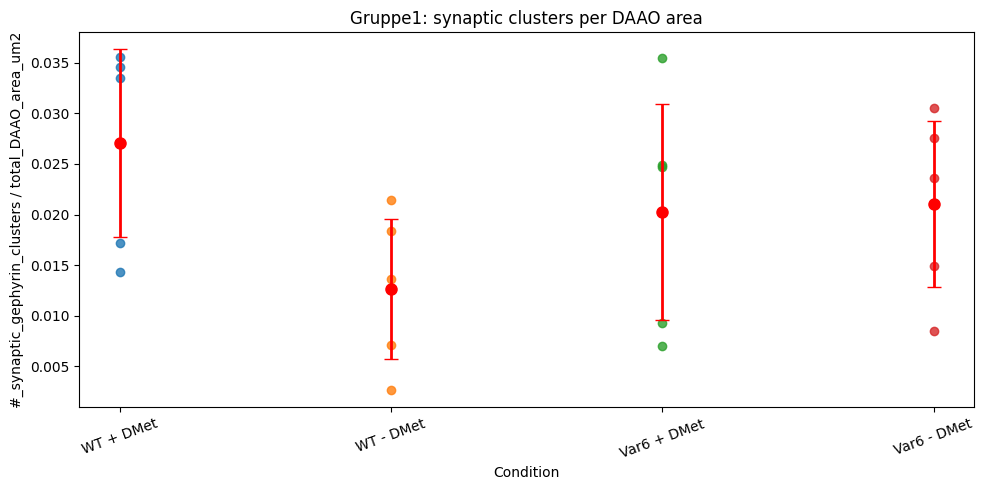

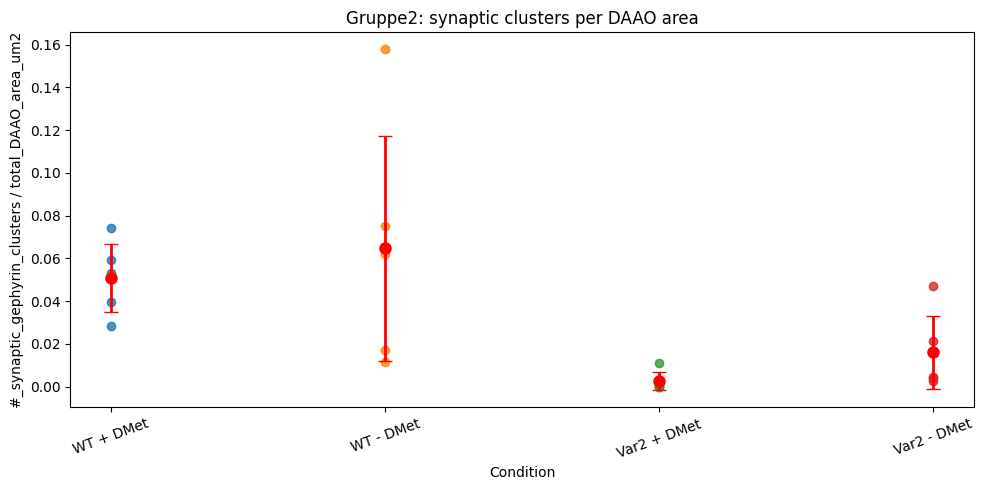

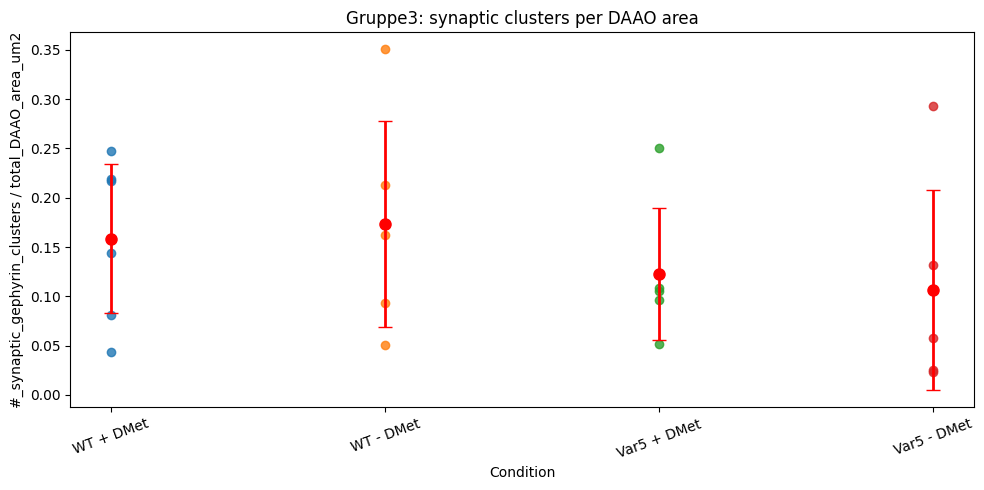

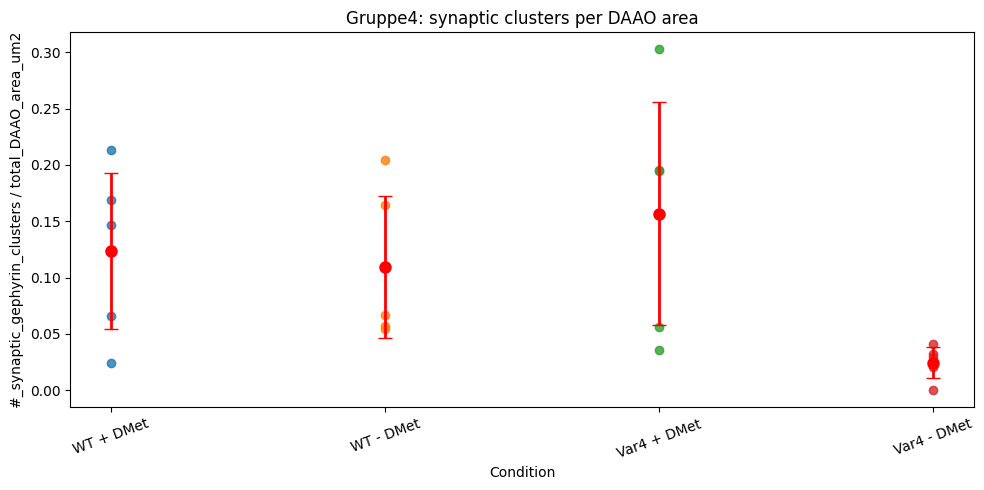

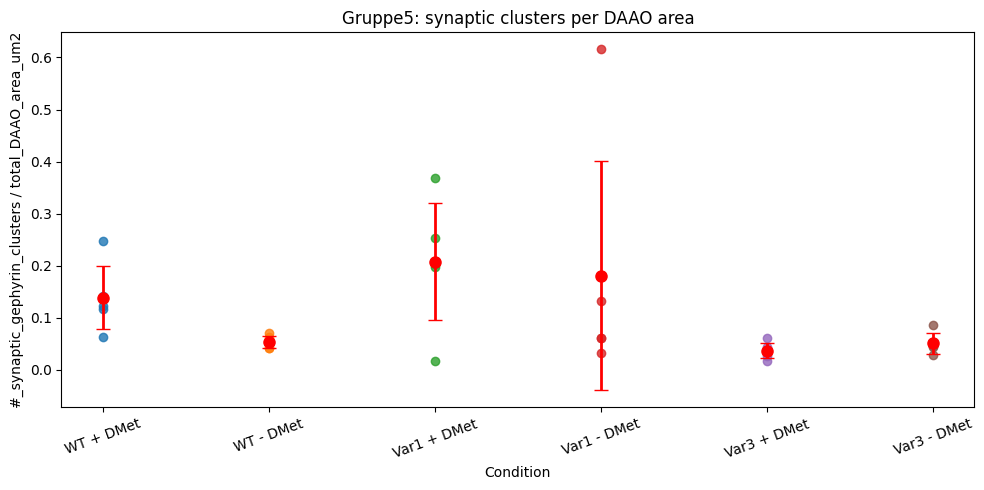

In [11]:
plot_df = final_df.copy()

plot_df["synaptic_clusters_per_DAAO_area"] = (
    plot_df["#_synaptic_gephyrin_clusters"]
    / plot_df["total_DAAO_area_um2"]
)

plot_df.loc[plot_df["total_DAAO_area_um2"] == 0, "synaptic_clusters_per_DAAO_area"] = np.nan

parsed_values = plot_df["source_lif"].apply(read_group_and_condition)
plot_df["Gruppe"] = parsed_values.str[0]
plot_df["condition"] = parsed_values.str[1]

failed_rows = plot_df[plot_df["Gruppe"].isna() | plot_df["condition"].isna()]
if not failed_rows.empty:
    print("These source_lif values could not be parsed:")
    display(failed_rows[["source_lif"]].drop_duplicates())

plot_df = plot_df.dropna(subset=["Gruppe", "condition"]).copy()

all_groups = sorted(plot_df["Gruppe"].unique(), key=group_sort_key)

for group_name in all_groups:
    group_df = plot_df[plot_df["Gruppe"] == group_name].copy()
    conditions = sorted(group_df["condition"].unique(), key=condition_sort_key)

    # Calculate means and standard deviations
    means = []
    stds = []
    for condition_name in conditions:
        values = group_df.loc[
            group_df["condition"] == condition_name,
            "synaptic_clusters_per_DAAO_area"
        ].dropna().to_numpy()
        means.append(np.mean(values))
        stds.append(np.std(values))

    plt.figure(figsize=(10, 5))
    
    # Plot error bars for mean ± std
    plt.errorbar(range(1, len(conditions)+1), means, yerr=stds, fmt='o', 
                 ecolor='red', color='red', capsize=5, linewidth=2, markersize=8,
                 label='mean ± std', zorder=5)

    for position, condition_name in enumerate(conditions, start=1):
        y_values = group_df.loc[
            group_df["condition"] == condition_name,
            "synaptic_clusters_per_DAAO_area"
        ].dropna().to_numpy()
        x_values = [position] * len(y_values)
        plt.scatter(x_values, y_values, alpha=0.8, zorder=3)

    plt.title(f"{group_name}: synaptic clusters per DAAO area")
    plt.xlabel("Condition")
    plt.ylabel("#_synaptic_gephyrin_clusters / total_DAAO_area_um2")
    plt.xticks(range(1, len(conditions)+1), conditions, rotation=20)
    plt.tight_layout()
    plt.show()

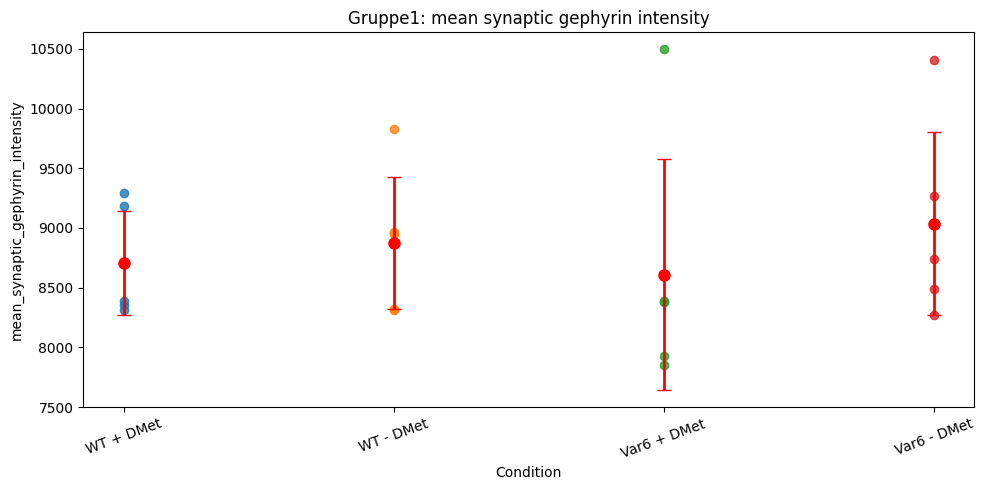

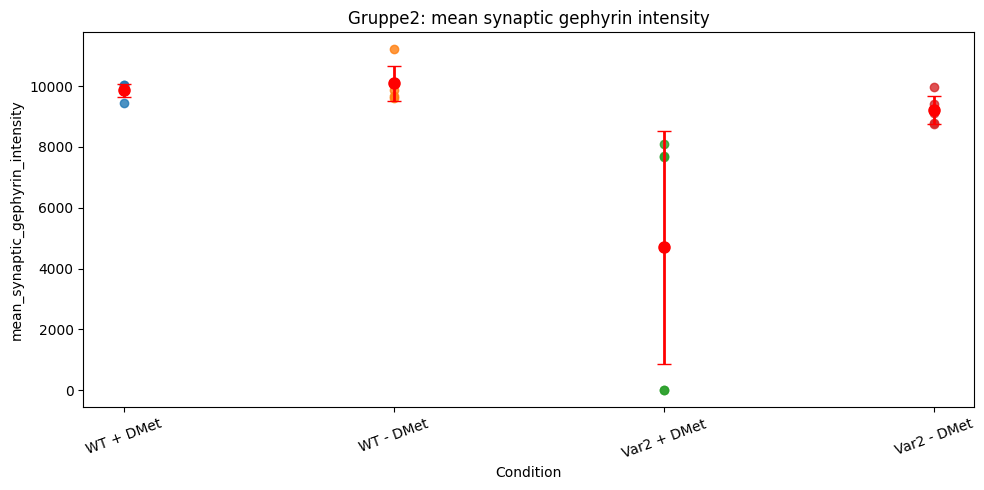

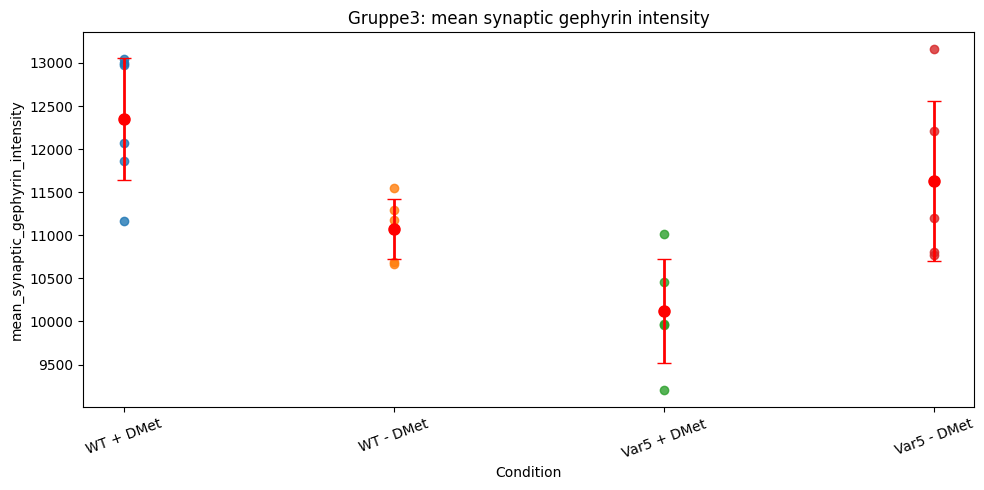

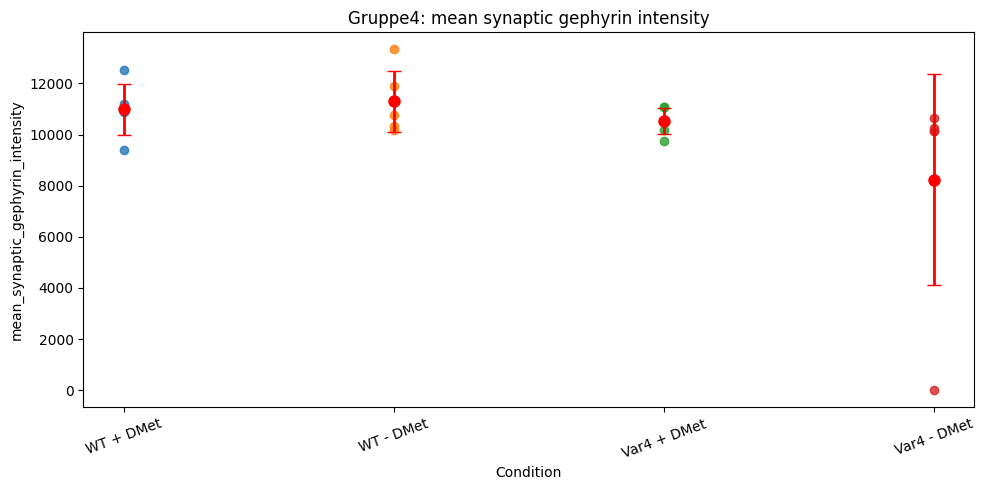

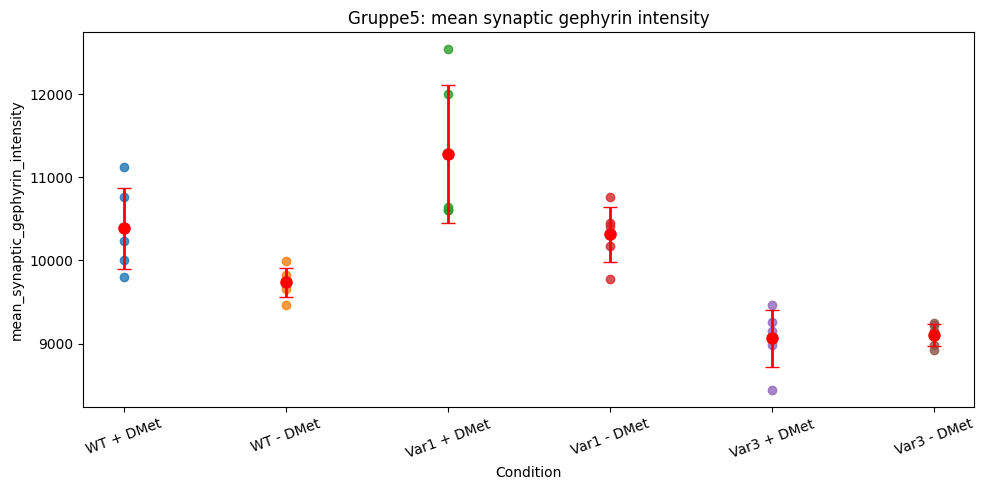

In [12]:
plot_df = final_df.copy()

parsed_values = plot_df["source_lif"].apply(read_group_and_condition)
plot_df["Gruppe"] = parsed_values.str[0]
plot_df["condition"] = parsed_values.str[1]

failed_rows = plot_df[plot_df["Gruppe"].isna() | plot_df["condition"].isna()]
if not failed_rows.empty:
    print("These source_lif values could not be parsed:")
    display(failed_rows[["source_lif"]].drop_duplicates())

plot_df = plot_df.dropna(subset=["Gruppe", "condition"]).copy()

all_groups = sorted(plot_df["Gruppe"].unique(), key=group_sort_key)

for group_name in all_groups:
    group_df = plot_df[plot_df["Gruppe"] == group_name].copy()
    conditions = sorted(group_df["condition"].unique(), key=condition_sort_key)

    # Calculate means and standard deviations
    means = []
    stds = []
    for condition_name in conditions:
        values = group_df.loc[
            group_df["condition"] == condition_name,
            "mean_synaptic_gephyrin_intensity"
        ].dropna().to_numpy()
        means.append(np.mean(values))
        stds.append(np.std(values))

    plt.figure(figsize=(10, 5))
    
    # Plot error bars for mean ± std
    plt.errorbar(range(1, len(conditions)+1), means, yerr=stds, fmt='o', 
                 ecolor='red', color='red', capsize=5, linewidth=2, markersize=8,
                 label='mean ± std', zorder=5)

    for position, condition_name in enumerate(conditions, start=1):
        y_values = group_df.loc[
            group_df["condition"] == condition_name,
            "mean_synaptic_gephyrin_intensity"
        ].dropna().to_numpy()
        x_values = [position] * len(y_values)
        plt.scatter(x_values, y_values, alpha=0.8, zorder=3)

    plt.title(f"{group_name}: mean synaptic gephyrin intensity")
    plt.xlabel("Condition")
    plt.ylabel("mean_synaptic_gephyrin_intensity")
    plt.xticks(range(1, len(conditions)+1), conditions, rotation=20)
    plt.tight_layout()
    plt.show()